In [8]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
import numpy as np
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
cd = "CDK174"
data_path =  f"D:\\K_Sunada\\result\\{cd}\\"

In [12]:

# from qutip import fidelity, Qobj
# from mpl_toolkits.mplot3d import Axes3D
# from programs.Analysis import polynomial_fit

from scipy.optimize import minimize
def rotation_ge(theta:float, rho):
    R = np.array([
        [1, 0, 0],
        [0, np.exp(1j*theta), 0],
        [0, 0, 1]
    ])
    return R.T.conj() @ rho @ R

def rotation_ef(phi, rho):
    R = np.array([
        [1, 0, 0],
        [0,1,0],
        [0, 0,np.exp(1j*phi)]
    ])
    return R.T.conj() @ rho @ R

def rotation(theta, phi, rho):
    return rotation_ef(phi, rotation_ge(theta, rho))

def optimal_angles(rhos, ideal_rhos):
    def ng_fid(angles):
        theta, phi = angles
        f = 0
        for rho, ideal_rho in zip(rhos, ideal_rhos):
            rot_rho = rotation(theta, phi, rho)
            f -= fidelity(Qobj(rot_rho), Qobj(ideal_rho))
        return f
    result = minimize(ng_fid, (np.pi/2, np.pi/2))
    return result.x

from Analysis import (
    lowpass
)
readout_lo_freq = 9.47
def extract_env(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def mode_func(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def overlap(wave1, wave2, time):
    norm1=np.sqrt(np.sum(np.abs(wave1)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(wave2)**2) * (time[1]-time[0]))
    m1_t = wave1 / norm1
    m2_t = wave2 / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave1)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

def show_tomography_result(name_dict:dict):
    rhos = []
    ideal_rhos = []
    for k, v in name_dict.items():
        _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
        drive_power = (datadict["signal"]["values"])
        meas_prob = []
        for _ in drive_power:
            l = [i for i in _ if i<np.inf]
            meas_prob.append(len([x for x in l if x<0.5]) / len(l))
        rhos.append(QST_MaxLik_Qutrit(meas_prob))
        ideal_rhos.append(v["ideal"])
    theta, phi = optimal_angles(rhos, ideal_rhos)
    print(theta, phi)
    rot_rhos = []
    fs = []
    fig = plt.figure(figsize=(20, 2)) ;i=1
    for rho, ideal_rho in zip(rhos, ideal_rhos):
        ax = fig.add_subplot(1, 6, i, projection="3d")
        rot_rho = rotation(theta, phi, rho)
        rot_rhos.append(rot_rho[:2, :2])
        ysq.matrix_histogram_complex(rot_rho, ax=ax)
        fs.append(fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2)
        i+=1
    print(f"{np.round(fs, decimals=5)}")
    plt.show()
    chi = QPT_cvx_Qubit(rot_rhos)
    chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
    ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
    plt.show()

    I = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ])
    print(f"Process fidelity : {fidelity(Qobj(I), Qobj(chi))**2 :.5f}")
    return chi

def chi_fidelity(chi:np.ndarray, chi_ideal:np.ndarray):
    return np.trace(chi @ chi_ideal)

2.4563300975077365 1.0850701272471481
[0.88314 0.68532 0.71082 0.6985  0.60067 0.38476]


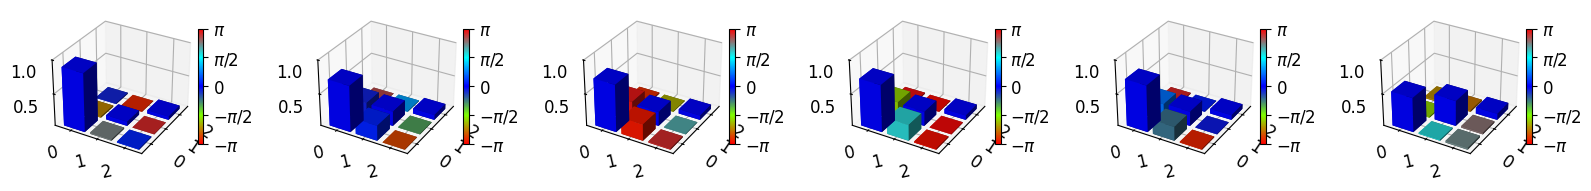

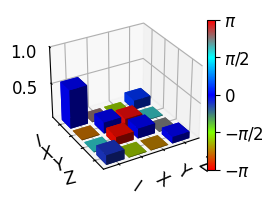

Process fidelity : 0.54197


array([[ 0.54197203+4.03149736e-15j, -0.00538799+4.43433195e-03j,
        -0.00259437-8.96744069e-03j,  0.12459579+4.24107825e-02j],
       [-0.00538799-4.43433195e-03j,  0.1541224 -9.01709263e-15j,
        -0.11385063+1.02971785e-02j, -0.00228399+6.89998725e-03j],
       [-0.00259437+8.96744069e-03j, -0.11385063-1.02971785e-02j,
         0.13858878+7.89646126e-15j, -0.00347349+3.58413100e-03j],
       [ 0.12459579-4.24107825e-02j, -0.00228399-6.89998725e-03j,
        -0.00347349-3.58413100e-03j,  0.09197797-3.68455266e-15j]])

In [13]:
# delay = 0, no pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2025-02-22", acquire_time="172927", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2025-02-22", acquire_time="173003", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2025-02-22", acquire_time="173040", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2025-02-22", acquire_time="173117", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2025-02-22", acquire_time="173153", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2025-02-22", acquire_time="173230", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

# _, datadict = search_datadict_miyamura(data_path, "2025-02-22", acquire_time="204301", name="form")
# time = np.unique(datadict["time"]["values"])
# waveform_abs = datadict["waveform_abs"]["values"]
# waveform_noabs = datadict["waveform_noabs"]["values"]
# env_abs = extract_env(time, waveform_abs, 9.35)
# env_noabs = extract_env(time, waveform_noabs, 9.35)

# _, datadict = search_datadict_miyamura(data_path, "2025-02-22", acquire_time="204301", name="photons_TD_comm_reflected_waveform")
# time_p = np.unique(datadict["time"]["values"])
# photon_rx = datadict["photon_rx"]["values"]
# env_rx = extract_env(time_p, photon_rx, 9.35)
# photon_tx = datadict["photon_tx"]["values"]
# env_tx = extract_env(time_p, photon_tx, 9.35)
# fig = plt.figure(figsize=(3,2))
# plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
# plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
# plt.plot(time_p, env_rx**2)
# plt.plot(time_p, env_tx**2)
# plt.xlabel("Time (ns)")
# plt.ylabel(r"$|\langle a \rangle|^2$")
# plt.legend(bbox_to_anchor=(1,1))
# plt.show()
# print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
# print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
# print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

-9.711607747670511e-12 -1.5489324972048534e-11


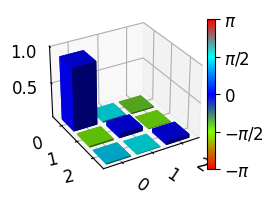

0.883


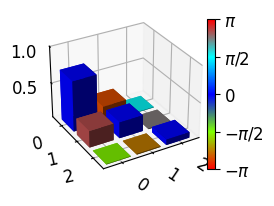

0.258


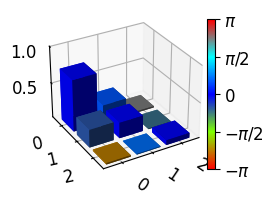

0.252


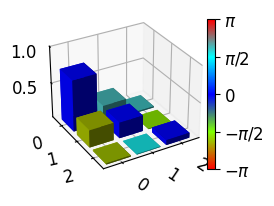

0.246


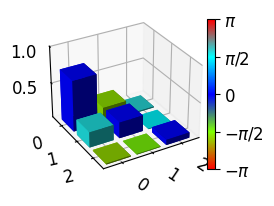

0.255


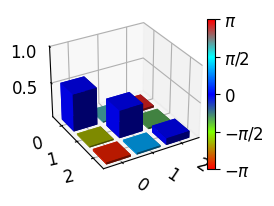

0.385


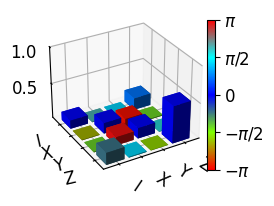

0.11592961574786291

In [11]:
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2